In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np

Import des librairies nécessaires

In [2]:
KEY_PATH = r"C:\Users\Administrateur\Documents\Formation Data Analyste\Projet final\urbanmove-489008-6c0d2b1a62ad.json"
PROJECT_ID = "urbanmove-489008"

credentials = service_account.Credentials.from_service_account_file(
KEY_PATH,
scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

client = bigquery.Client(credentials=credentials, project=PROJECT_ID)
print("Connexion BigQuery OK")

Connexion BigQuery OK


Connexion à BigQuery

In [3]:
QUERY = """
SELECT *
FROM urbanmove-489008.UrbanMove.table_previsions_surface
"""

df = client.query(QUERY).to_dataframe()
print(f"{len(df):,} lignes chargées — {df.shape[1]} colonnes")
df.head()

1,437,877 lignes chargées — 15 colonnes


,date_jour,annee,mois,jour,jour_semaine,id_ligne,mode_transport,precipitation,vent,neige,temperature,meteo_defavorable,retard_moyen_minutes,accessibilite,air_conditionne
0,2024-12-11,2024,12,11,Wednesday,C01981,bus,0.0,12.9,0.0,5.2,False,67.85,false,false
1,2024-12-11,2024,12,11,Wednesday,C01463,bus,0.0,12.9,0.0,5.2,False,71.47,false,unknown
2,2024-12-13,2024,12,13,Friday,C00062,bus,0.0,8.4,0.0,2.1,True,83.96,unknown,false
3,2024-12-13,2024,12,13,Friday,C00459,bus,0.0,8.4,0.0,2.1,True,84.05,unknown,unknown
4,2024-12-13,2024,12,13,Friday,C00765,bus,0.0,8.4,0.0,2.1,True,83.96,false,true


Import des données et création du dataframe

In [4]:
df_model = df.copy()
df_model = df_model.drop(columns = ['date_jour'])
df_model["meteo_defavorable"] = df_model["meteo_defavorable"].astype(int)

categorical_columns = ['jour_semaine', 'id_ligne', 'mode_transport', 'accessibilite', 'air_conditionne']
encoder = LabelEncoder()
for col in categorical_columns:
    df_model[col] = encoder.fit_transform(df_model[col])

df_model.head()

,annee,mois,jour,jour_semaine,id_ligne,mode_transport,precipitation,vent,neige,temperature,meteo_defavorable,retard_moyen_minutes,accessibilite,air_conditionne
0,2024,12,11,6,1434,0,0.0,12.9,0.0,5.2,0,67.85,0,0
1,2024,12,11,6,1097,0,0.0,12.9,0.0,5.2,0,71.47,0,3
2,2024,12,13,0,43,0,0.0,8.4,0.0,2.1,1,83.96,2,0
3,2024,12,13,0,319,0,0.0,8.4,0.0,2.1,1,84.05,2,3
4,2024,12,13,0,546,0,0.0,8.4,0.0,2.1,1,83.96,0,2


Préparation des données pour la forêt aléatoire

In [5]:
X = df_model.drop(columns = ['retard_moyen_minutes'])
y = df_model['retard_moyen_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Ensemble d'entraînement : {X_train.shape}, Ensemble de test : {X_test.shape}")

Ensemble d'entraînement : (1150301, 13), Ensemble de test : (287576, 13)


Division des données pour l'entrainement

In [6]:
X_sample = X_train.sample(n=100000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Définition de la grille de paramètres
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

rf = RandomForestRegressor()

# Mise en place du test (n_iter=10 testera 10 combinaisons au hasard)
# cv=3 signifie une validation croisée en 3 étapes
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, # Utilise tous les processeurs de votre instance GCP
    verbose=2,
    random_state = 42
)

# Exécution sur un échantillon pour gagner du temps au début
# (Prendre 100k lignes pour le réglage est souvent suffisant)
random_search.fit(X_sample, y_sample)

print(f"Meilleurs paramètres : {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}


Test pour définir les meilleurs paramètres pour la forêt aléatoire sur un échantillon de 100k lignes

In [7]:
# Création et entraînement de la forêt aléatoire
regressor = RandomForestRegressor(n_estimators = 100, min_samples_split = 5, min_samples_leaf = 2, max_depth = 10, random_state=42)
regressor.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Création et entrainement de la forêt aléatoire

In [8]:
# Prédictions sur l'ensemble de test
y_pred = regressor.predict(X_test)
# Calcul des métriques
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de Détermination (R²) : {r2:.2f}")

Erreur Quadratique Moyenne (MSE) : 4.30
Coefficient de Détermination (R²) : 0.99


Prédiction et évaluation (score) de notre modèle

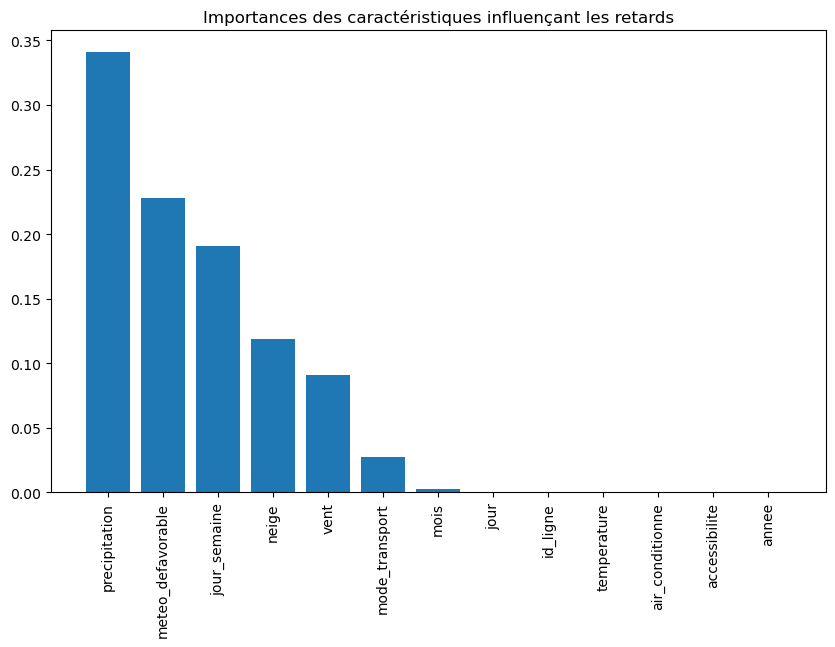

In [9]:
# Importances des variables
importances = regressor.feature_importances_
indices = np.argsort(importances)[::-1]
# Tracer les importances
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Importances des caractéristiques influençant les retards")
plt.show()

Visualisation des variables classées par ordre d'influence sur les retards

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 21.4min
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed: 24.7min finished


  RÉSULTATS REPEATED K-FOLDS (5 splits × 10 répétitions)

Métrique                      Mean       Std       Min       Max
-------------------------------------------------------
R² TEST                     0.9892    0.0005    0.9880    0.9903
R² TRAIN                    0.9904    0.0001    0.9902    0.9906
MAE TEST                    1.4925    0.0084    1.4692    1.5084
MSE TEST                    4.8879    0.2009    4.5132    5.4307

Gap Train/Test R² : 0.0012  →  ✅ Pas d'overfitting significatif


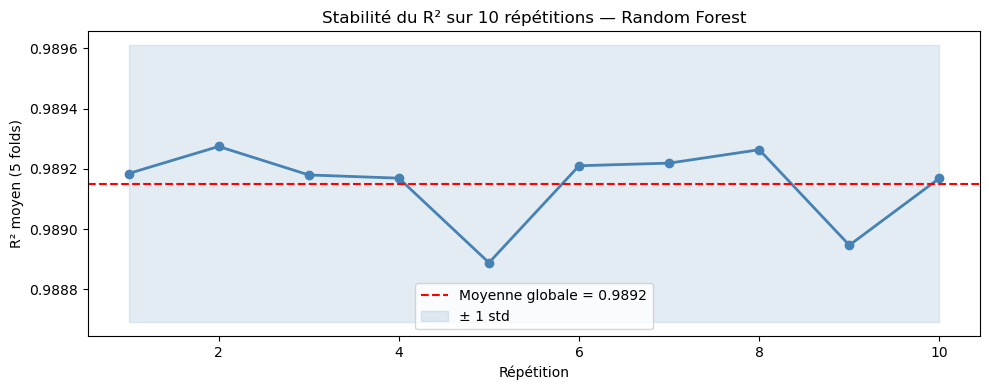

In [10]:
rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_results = cross_validate(
    estimator=regressor,
    X=X_sample,
    y=y_sample,
    cv=rkf,
    scoring={
        'r2':  'r2',
        'mae': 'neg_mean_absolute_error',
        'mse': 'neg_mean_squared_error'
    },
    return_train_score=True,
    n_jobs=4,
    verbose=1
)

r2_test  = cv_results['test_r2']
r2_train = cv_results['train_r2']
mae_test = -cv_results['test_mae']
mse_test = -cv_results['test_mse']

print("=" * 55)
# ✏️ Mise à jour du titre
print("  RÉSULTATS REPEATED K-FOLDS (5 splits × 10 répétitions)")
print("=" * 55)
print(f"\n{'Métrique':<25} {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 55)
print(f"{'R² TEST':<25} {r2_test.mean():>8.4f}  {r2_test.std():>8.4f}  {r2_test.min():>8.4f}  {r2_test.max():>8.4f}")
print(f"{'R² TRAIN':<25} {r2_train.mean():>8.4f}  {r2_train.std():>8.4f}  {r2_train.min():>8.4f}  {r2_train.max():>8.4f}")
print(f"{'MAE TEST':<25} {mae_test.mean():>8.4f}  {mae_test.std():>8.4f}  {mae_test.min():>8.4f}  {mae_test.max():>8.4f}")
print(f"{'MSE TEST':<25} {mse_test.mean():>8.4f}  {mse_test.std():>8.4f}  {mse_test.min():>8.4f}  {mse_test.max():>8.4f}")

gap = r2_train.mean() - r2_test.mean()
print(f"\nGap Train/Test R² : {gap:.4f}", end="  →  ")
if gap > 0.05:
    print("⚠️  Possible overfitting détecté")
else:
    print("✅ Pas d'overfitting significatif")


r2_par_rep = r2_test.reshape(10, 5).mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), r2_par_rep, marker='o', linewidth=2, color='steelblue')
plt.axhline(r2_test.mean(), color='red', linestyle='--', label=f'Moyenne globale = {r2_test.mean():.4f}')
plt.fill_between(range(1, 11),
                 r2_test.mean() - r2_test.std(),
                 r2_test.mean() + r2_test.std(),
                 alpha=0.15, color='steelblue', label='± 1 std')
plt.xlabel("Répétition")
plt.ylabel("R² moyen (5 folds)")
plt.title("Stabilité du R² sur 10 répétitions — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

Validation croisée répétée 10 fois pour vérifier la fiabilité du modèle

In [11]:
df_model_2 = df.copy()
df_model_2 = df_model_2.drop(columns = ['date_jour'])
df_model_2["meteo_defavorable"] = df_model_2["meteo_defavorable"].astype(int)
df_model_2['annee'] = df_model_2['annee'].astype(int)
df_model_2['mois'] = df_model_2['mois'].astype(int)
df_model_2['jour'] = df_model_2['jour'].astype(int)

# Colonnes numériques et catégoriques
numerical_columns = ['temperature', 'mois', 'annee', 'jour', 'precipitation', 'vent', 'neige', 'meteo_defavorable']
categorical_columns = ['id_ligne', 'mode_transport', 'accessibilite', 'air_conditionne', 'jour_semaine']
# Séparer les caractéristiques et la cible
X = df_model_2.drop(columns = ['retard_moyen_minutes'])
y = df_model_2['retard_moyen_minutes']
# Prétraiter les données
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),  # Normalisation des numériques
        ("cat", OneHotEncoder(), categorical_columns),  # Encodage des catégories
    ]
)
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Appliquer le préprocesseur
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
# Vérification
print(f"Dimensions après prétraitement - Entraînement : {X_train_transformed.shape}")

Dimensions après prétraitement - Entraînement : (1150301, 1993)


Préparation et division des données pour le réseau de neurones

In [12]:
# Construire le modèle
model = Sequential([
    Input(shape=(X_train_transformed.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.2),  # Dropout de 20%
    Dense(64, activation="relu"),
    Dropout(0.1),  # Dropout de 10%
    Dense(32, activation='relu'),
    Dense(1, activation="linear")  # Couche de sortie
])
# Résumé du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       255,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,601 (1.01 MB)

 Trainable params: 265,601 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Construction du modèle de réseau de neurones

In [13]:
# Compiler le modèle
model.compile(
    optimizer='adam', 
    loss='mean_squared_error',  # Perte pour la régression
    metrics=['mean_absolute_error']  # MAE pour l'évaluation
)

Compilation du modèle

In [14]:
history = model.fit(
    X_train_transformed, y_train,
    epochs=100,           
    batch_size=1024,     
    validation_split=0.2,
    verbose=2
)

Epoch 1/100
899/899 - 63s - 70ms/step - loss: 517.4212 - mean_absolute_error: 13.1272 - val_loss: 92.6361 - val_mean_absolute_error: 6.5348
Epoch 2/100
899/899 - 40s - 45ms/step - loss: 118.6670 - mean_absolute_error: 7.7447 - val_loss: 56.5919 - val_mean_absolute_error: 5.0758
Epoch 3/100
899/899 - 34s - 38ms/step - loss: 90.5000 - mean_absolute_error: 6.7575 - val_loss: 42.2661 - val_mean_absolute_error: 4.4550
Epoch 4/100
899/899 - 32s - 35ms/step - loss: 72.4386 - mean_absolute_error: 5.9783 - val_loss: 31.2607 - val_mean_absolute_error: 3.6848
Epoch 5/100
899/899 - 29s - 33ms/step - loss: 60.8193 - mean_absolute_error: 5.4906 - val_loss: 24.0310 - val_mean_absolute_error: 3.3998
Epoch 6/100
899/899 - 29s - 32ms/step - loss: 52.8291 - mean_absolute_error: 5.1602 - val_loss: 22.6831 - val_mean_absolute_error: 3.4576
Epoch 7/100
899/899 - 40s - 44ms/step - loss: 44.9440 - mean_absolute_error: 4.7887 - val_loss: 27.0523 - val_mean_absolute_error: 3.9796
Epoch 8/100
899/899 - 43s - 47m

Entrainement du modèle

In [15]:
# Évaluer le modèle
loss, mae = model.evaluate(X_test_transformed, y_test)
print(f"Perte (MSE) sur le test : {loss:.2f}")
print(f"Erreur absolue moyenne (MAE) : {mae:.2f}")

y_pred = model.predict(X_test_transformed)
r2 = r2_score(y_test, y_pred)
print(f"R² : {r2:.2f}")

8987/8987 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 12.1504 - mean_absolute_error: 2.3441
Perte (MSE) sur le test : 12.15
Erreur absolue moyenne (MAE) : 2.34
8987/8987 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step
R² : 0.97


Evaluation (score) du modèle

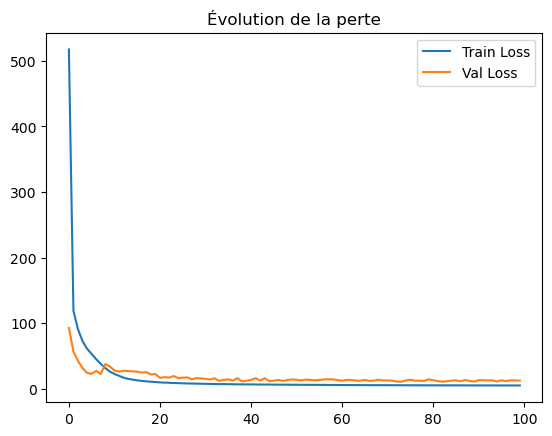

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la perte')
plt.legend()

Visualisation de l'évolution de la perte

Text(0.5, 1.0, 'Comparaison Réel vs Prédit')

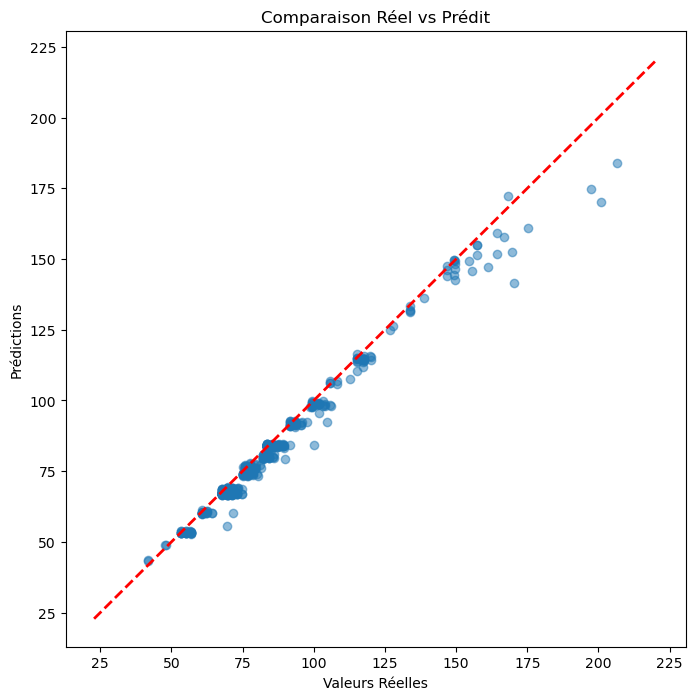

In [17]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test[:500], y_pred[:500], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles')
plt.ylabel('Prédictions')
plt.title('Comparaison Réel vs Prédit')

Visualisation comparative entre le réel et la prédiction

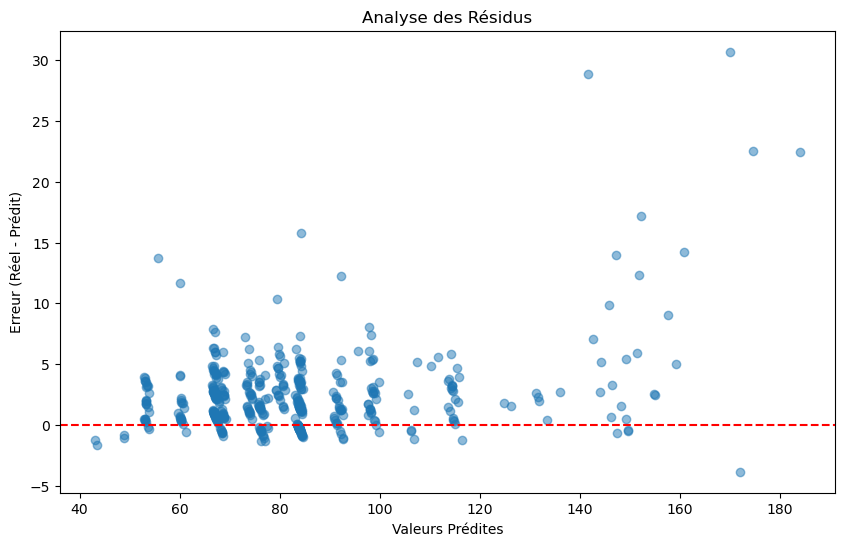

In [18]:
residus = y_test.values.flatten() - y_pred.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred[:500], residus[:500], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valeurs Prédites')
plt.ylabel('Erreur (Réel - Prédit)')
plt.title('Analyse des Résidus')
plt.show()

Visualisation des résidus

In [19]:
df_prev = pd.read_csv('Conditions surface demain.csv')

df_model_prev = df_prev.copy()
categorical_columns_prev = ['id_ligne', 'mode_transport', 'accessibilite', 'air_conditionne']
encoder = LabelEncoder()
for col in categorical_columns:
    df_model_prev[col] = encoder.fit_transform(df_model_prev[col])

df_model_prev.head()

,annee,mois,jour,jour_semaine,id_ligne,mode_transport,precipitation,vent,neige,temperature,meteo_defavorable,accessibilite,air_conditionne
0,2026,3,13,0,241,0,2.9,25.0,0.0,8.5,0,2,2
1,2026,3,13,0,1154,0,2.9,25.0,0.0,8.5,0,1,2
2,2026,3,13,0,1211,0,2.9,25.0,0.0,8.5,0,2,3
3,2026,3,13,0,1655,0,2.9,25.0,0.0,8.5,0,1,2
4,2026,3,13,0,258,0,2.9,25.0,0.0,8.5,0,2,3


Import données de demain (vendredi 13/03/2026) pour la prévision

In [20]:
df_prev['retard_prevu'] = regressor.predict(df_model_prev)

# Création de la table classée par retard
table_classement = df_prev[['id_ligne', 'mode_transport', 'retard_prevu']].sort_values(by='retard_prevu', ascending=False)
table_classement['retard_prevu'] = table_classement['retard_prevu'].round(2)

print("Top 10 des lignes les plus impactées :")
print(table_classement.head(10))

Top 10 des lignes les plus impactées :
     id_ligne mode_transport  retard_prevu
1388   C02834            bus        101.73
973    C02453            bus        101.49
1865   C02460            bus        101.49
1550   C02452            bus        101.48
420    C02455            bus        101.48
250    C02456            bus        101.48
163    C02461            bus        101.47
686    C02451            bus        101.47
132    C02458            bus        101.47
1427   C02459            bus        101.47


Traitement des données via la forêt aléatoire et sortie du top 10 des lignes qui cumuleraient le plus de retard